This notebook is an example using only one minibox of what the script does for all the miniboxes we divided the simulation into

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
# ASTRID cosmology values
hubble, z = 0.6774, 2.5

# Calculating P1D 

In [10]:
data = '/pscratch/sd/l/lflores/astrid_hcd_outputs/FFTs/ffts_0.3_21.3/minibox_00.hdf5'
Nmbox = 25

with h5py.File(data, 'r') as f:
    print('Atributes:')
    for k in f.attrs.keys():
        print(f'{k} = {f.attrs[k]}')
    print('----------------') 
    # Atributes
    logNHi_min = f.attrs['logNHI_min']
    logNHi_max = f.attrs['logNHI_max']
    smth_factor = f.attrs['Smoothing factor']
    Lbox = f.attrs['box_size_Mpch']
    Lmbox = f.attrs['minibox_size_Mpch']
    Nsk = f.attrs['skewers_per_side']
    Np = f.attrs['pixels_per_skewer']
    Pw = f.attrs['pixel_width_Mpch']
    Ssk = f.attrs['skewer_separation_Mpch']
    print('Data:')
    print(f.keys())
    # Data
    fft_tot = f['fft_tot'][:]
    print('fft_tot shape:', fft_tot.shape)
    fft_lya = f['fft_lya'][:]
    print('fft_lya shape:', fft_lya.shape)
    fft_hcd = f['fft_hcd'][:]
    print('fft_hcd shape:', fft_hcd.shape)
    fft_lyahcd = f['fft_lyahcd'][:]
    print('fft_lyahcd shape:', fft_lyahcd.shape)
    k_los = f['k_los'][:]
    print('k_los shape', k_los.shape)
    C = f['C'][()]
    print('C = ', C)
    mask = f['mask'][:]


Atributes:
Smoothing factor = 0.3
box_size_Mpch = 250
logNHI_max = 21.3
logNHI_min = 0
minibox_size_Mpch = 50.0
pixel_width_Mpch = 0.1
pixels_per_skewer = 2500
skewer_separation_Mpch = 0.5
skewers_per_side = 100
----------------
Data:
<KeysViewHDF5 ['C', 'colden', 'fft_hcd', 'fft_lya', 'fft_lyahcd', 'fft_tot', 'k_los', 'mask']>
fft_tot shape: (10000, 1251)
fft_lya shape: (10000, 1251)
fft_hcd shape: (10000, 1251)
fft_lyahcd shape: (10000, 1251)
k_los shape (1251,)
C =  0.005228302549354691


## Total

In [17]:
mask.shape, fft_tot.shape

((10000,), (10000, 1251))

In [ ]:
mask2d = mask

In [18]:
p1ds_tot = fft_tot*fft_tot.conjugate()*Lbox/(Np**2)
del fft_tot
P1d_tot = np.nanmean(p1ds_tot, axis=0)
del p1ds_tot

In [19]:
P1d_tot

array([1.18019246e+00+0.00000000e+00j, 9.00534940e-01+1.59030296e-19j,
       7.61049694e-01+2.20254811e-19j, ...,
       1.45373134e-05-9.36692439e-25j, 1.45530087e-05-2.14417387e-24j,
       1.45221476e-05+0.00000000e+00j], shape=(1251,))

/pscratch/sd/l/lflores/hcd_env/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/pscratch/sd/l/lflores/hcd_env/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


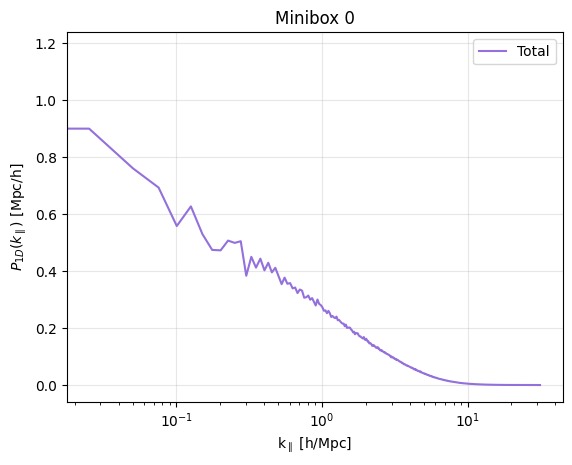

In [20]:
plt.plot(k_los, P1d_tot, color='mediumpurple', label='Total')
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc/h]')
plt.title('Minibox 0');

## Lya

In [21]:
p1ds_lya = fft_lya*fft_lya.conjugate()*Lbox/(Np**2)
P1d_lya = np.nanmean(p1ds_lya, axis=0)
del p1ds_lya

## HCDs

In [22]:
p1ds_hcd = fft_hcd*fft_hcd.conjugate()*Lbox/(Np**2)
P1d_hcd = np.nanmean(p1ds_hcd, axis=0)
del p1ds_hcd

## LyaxHCD

In [23]:
p1ds_lyahcd = fft_lya*fft_hcd.conjugate()*Lbox/(Np**2)
P1d_lyahcd = np.nanmean(p1ds_lyahcd, axis=0)
del p1ds_lyahcd

## 3Lya

In [24]:
p1ds_3lya = fft_lyahcd*fft_lya.conjugate()*Lbox/(Np**2)
P1d_3lya = np.nanmean(p1ds_3lya, axis=0)
del p1ds_3lya

## 3HCD

In [25]:
p1ds_3hcd = fft_lyahcd*fft_hcd.conjugate()*Lbox/(Np**2)
P1d_3hcd = np.nanmean(p1ds_3hcd, axis=0)
del p1ds_3hcd

## 4

In [26]:
p1ds_4 = (fft_lyahcd*fft_lyahcd.conjugate()-C**2)*Lbox/(Np**2)
P1d_4 = np.nanmean(p1ds_4, axis=0)
del p1ds_4

We have to make sure that p1d_tot = the sum of all contributions /(1 + C)^2

In [27]:
P1d_34 = 2*P1d_3lya + 2*P1d_3hcd + P1d_4
P1d_model = (P1d_lya + P1d_hcd + (2*P1d_lyahcd) + P1d_34)/((1+C)**2)

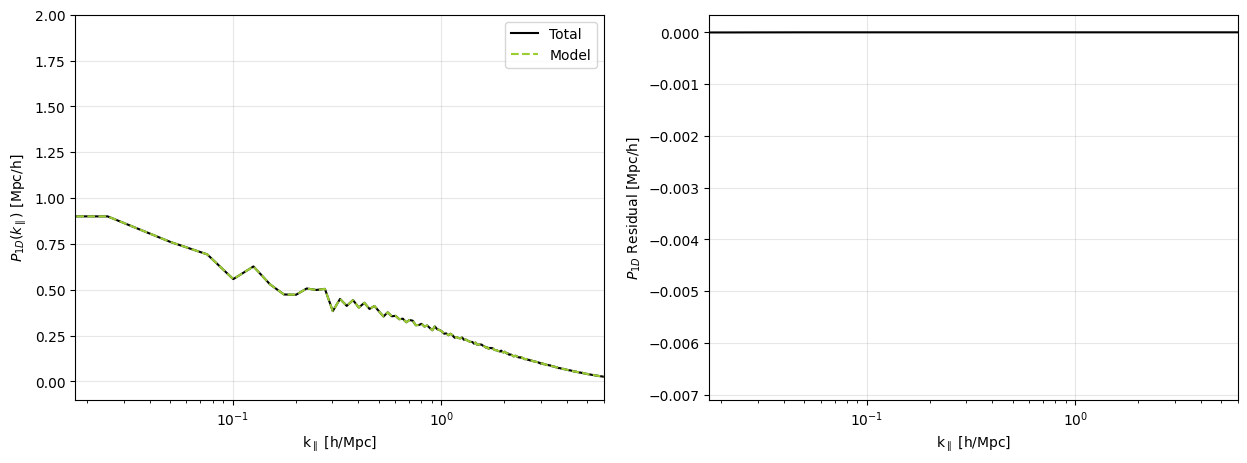

In [28]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_los, P1d_tot, color='k', label='Total')
plt.plot(k_los, P1d_model, linestyle='--', color='yellowgreen', label='Model')
plt.xscale('log')
plt.ylim(-0.1, 2)
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc/h]');

plt.subplot(1, 2, 2)
plt.plot(k_los, P1d_tot-P1d_model, color='k')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_{1D}$ Residual [Mpc/h]');

Great!

# Final measurements

Once we have run the script and calculated the different contributions for all the miniboxes we splitted the simulation box, we can "merge" all the statistics back together

In [3]:
data = '/pscratch/sd/l/lflores/astrid_hcd_outputs/p1ds_0.3_21.3.hdf5'

with h5py.File(data, 'r') as f:
    print('Atributes:')
    for m in f.attrs.keys():
        print(f'{m} = {f.attrs[m]}')
    print('----------------') 
    print('Data:')
    print(f.keys())
    k_los = f['k_los'][:]
    print('k_los shape:', k_los.shape)
    p1ds_tot = f['p1d_tot'][:]
    print('p1ds_tot shape:', p1ds_tot.shape)
    p1ds_lya = f['p1d_lya'][:]
    print('p1ds_lya shape:', p1ds_lya.shape)
    p1ds_hcd = f['p1d_hcd'][:]
    print('p1ds_hcd shape:', p1ds_hcd.shape)
    p1ds_lyahcd = f['p1d_lyahcd'][:]
    print('p1ds_lyahcd shape:', p1ds_lyahcd.shape)
    p1ds_3lya = f['p1d_3lya'][:]
    print('p1d_3lya shape:', p1ds_3lya.shape)
    p1ds_3hcd = f['p1d_3hcd'][:]
    print('p1ds_3hcd shape:', p1ds_3hcd.shape)
    p1ds_4 = f['p1d_4'][:]
    print('p1ds_4 shape:', p1ds_4.shape)
    Cs = f['C'][()]
    print('Cs shape = ', Cs.shape)
    mask = f['mask'][:]
    print('mask shape:', mask.shape)

Atributes:
Smoothing factor = 0.3
logNHI_max = 21.3
logNHI_min = 0
minibox_size_Mpch = 250
pixel_width_Mpch = 0.1
pixels_per_skewer = 2500
skewer_separation_Mpch = 0.5
skewers_per_side = 100
----------------
Data:
<KeysViewHDF5 ['C', 'k_los', 'mask', 'p1d_3hcd', 'p1d_3lya', 'p1d_4', 'p1d_hcd', 'p1d_lya', 'p1d_lyahcd', 'p1d_tot']>
k_los shape: (1251,)
p1ds_tot shape: (25, 1251)
p1ds_lya shape: (25, 1251)
p1ds_hcd shape: (25, 1251)
p1ds_lyahcd shape: (25, 1251)
p1d_3lya shape: (25, 1251)
p1ds_3hcd shape: (25, 1251)
p1ds_4 shape: (25, 1251)
Cs shape =  (25,)
mask shape: (10000,)


WARNING: p1ds are in Mpc/h units and k_los in h/Mpc

In [18]:
k_los /= hubble  # In Mpc^-1
p1ds_tot *= hubble  # In Mpc
p1ds_lya *= hubble 
p1ds_hcd *= hubble 
p1ds_lyahcd *= hubble 
p1ds_3lya *= hubble 
p1ds_3hcd *= hubble 
p1ds_4 *= hubble 

In [19]:
p1ds_34 = 2*p1ds_3lya + 2*p1ds_3hcd + p1ds_4
p1d_model = []
for i, Cs_value in enumerate(Cs):
    p1d_model.append((p1ds_lya[i, :] + p1ds_hcd[i, :] + (2*p1ds_lyahcd[i, :]) + p1ds_34[i, :])/((1+Cs_value)**2))
p1d_model = np.array(p1d_model)
P1d_model = np.mean(p1d_model, axis=0)

In [20]:
Nmbox = p1ds_tot[:, 0].shape[0]
P1d_tot, P1d_std_tot = np.mean(p1ds_tot, axis=0), np.std(p1ds_tot, axis=0)/np.sqrt(Nmbox-1)
P1d_lya, P1d_std_lya = np.mean(p1ds_lya, axis=0), np.std(p1ds_lya, axis=0)/np.sqrt(Nmbox-1)
P1d_hcd, P1d_std_hcd = np.mean(p1ds_hcd, axis=0), np.std(p1ds_hcd, axis=0)/np.sqrt(Nmbox-1)
P1d_lyahcd, P1d_std_lyahcd = np.mean(p1ds_lyahcd, axis=0), np.std(p1ds_lyahcd, axis=0)/np.sqrt(Nmbox-1)
P1d_3lya, P1d_std_3lya = np.mean(p1ds_3lya, axis=0), np.std(p1ds_3lya, axis=0)/np.sqrt(Nmbox-1)
P1d_3hcd, P1d_std_3hcd = np.mean(p1ds_3hcd, axis=0), np.std(p1ds_3hcd, axis=0)/np.sqrt(Nmbox-1)
P1d_4, P1d_std_4 = np.mean(p1ds_4, axis=0), np.std(p1ds_4, axis=0)/np.sqrt(Nmbox-1)

In [21]:
p1d_aprox, p1d_aprox_vega = [], []
p1d_aprox_std, p1d_aprox_vega_std = [], []
for i, Cs_value in enumerate(Cs):
    p1d_aprox.append(p1ds_lya[i, :] + p1ds_hcd[i, :] + (2*p1ds_lyahcd[i, :])/((1 + Cs_value)**2))
    p1d_aprox_vega.append(p1ds_lya[i, :] + p1ds_hcd[i, :] + (2*p1ds_lyahcd[i, :]))
p1d_aprox, p1d_aprox_vega = np.array(p1d_aprox), np.array(p1d_aprox_vega)          
P1d_aprox, P1d_std_aprox = np.mean(p1d_aprox, axis=0), np.std(p1d_aprox, axis=0)
P1d_aprox_vega, P1d_std_aprox_vega = np.mean(p1d_aprox_vega, axis=0), np.std(p1d_aprox_vega, axis=0)

Let's make the mean of all the boxes

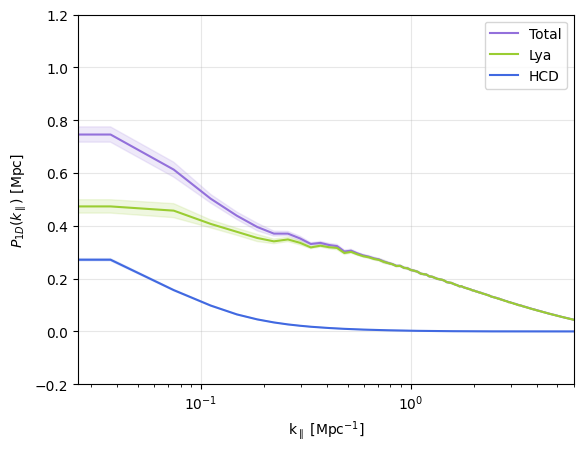

In [22]:
plt.plot(k_los, P1d_tot, color='mediumpurple', label='Total')
plt.fill_between(k_los, (P1d_tot-P1d_std_tot), (P1d_tot+P1d_std_tot), color='mediumpurple', alpha=0.15)
plt.plot(k_los, P1d_lya, color='yellowgreen', label='Lya')
plt.fill_between(k_los, (P1d_lya-P1d_std_lya), (P1d_lya+P1d_std_lya), color='yellowgreen', alpha=0.15)
plt.plot(k_los, P1d_hcd, color='royalblue', label='HCD')
plt.fill_between(k_los, (P1d_hcd-P1d_std_hcd), (P1d_hcd+P1d_std_hcd), color='royalblue', alpha=0.15)
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.ylim(-0.2, 1.2)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]');

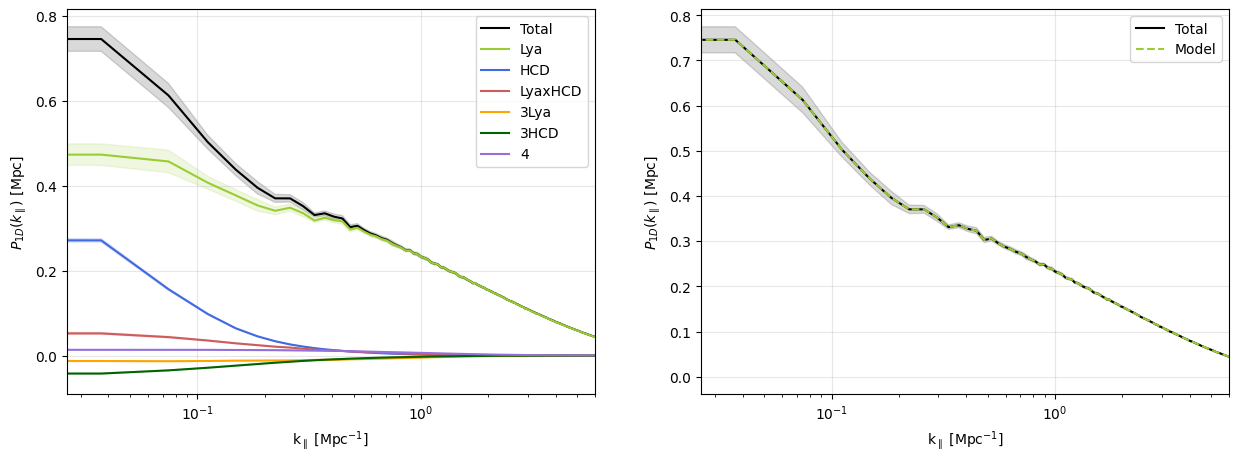

In [23]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_los, P1d_tot, color='k', label='Total')
plt.fill_between(k_los, (P1d_tot-P1d_std_tot), (P1d_tot+P1d_std_tot), color='k', alpha=0.15)
plt.plot(k_los, P1d_lya, color='yellowgreen', label='Lya')
plt.fill_between(k_los, (P1d_lya-P1d_std_lya), (P1d_lya+P1d_std_lya), color='yellowgreen', alpha=0.15)
plt.plot(k_los, P1d_hcd, color='royalblue', label='HCD')
plt.fill_between(k_los, (P1d_hcd-P1d_std_hcd), (P1d_hcd+P1d_std_hcd), color='royalblue', alpha=0.15)
plt.plot(k_los, P1d_lyahcd, color='indianred', label='LyaxHCD')
plt.fill_between(k_los, (P1d_lyahcd-P1d_std_lyahcd), (P1d_lyahcd+P1d_std_lyahcd), color='indianred', alpha=0.15)
plt.plot(k_los, P1d_3lya, color='orange', label='3Lya')
plt.fill_between(k_los, (P1d_3lya-P1d_std_3lya), (P1d_3lya+P1d_std_3lya), color='orange', alpha=0.15)
plt.plot(k_los, P1d_3hcd, color='darkgreen', label='3HCD')
plt.fill_between(k_los, (P1d_3hcd-P1d_std_3hcd), (P1d_3hcd+P1d_std_3hcd), color='darkgreen', alpha=0.15)
plt.plot(k_los, P1d_4, color='mediumpurple', label='4')
plt.fill_between(k_los, (P1d_4-P1d_std_4), (P1d_4+P1d_std_4), color='mediumpurple', alpha=0.15)

plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]')


plt.subplot(1, 2, 2)
plt.plot(k_los, P1d_tot, color='k', label='Total')
plt.fill_between(k_los, (P1d_tot-P1d_std_tot), (P1d_tot+P1d_std_tot), color='k', alpha=0.15)
plt.plot(k_los, P1d_model, linestyle='--', color='yellowgreen', label='Model')

plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]');

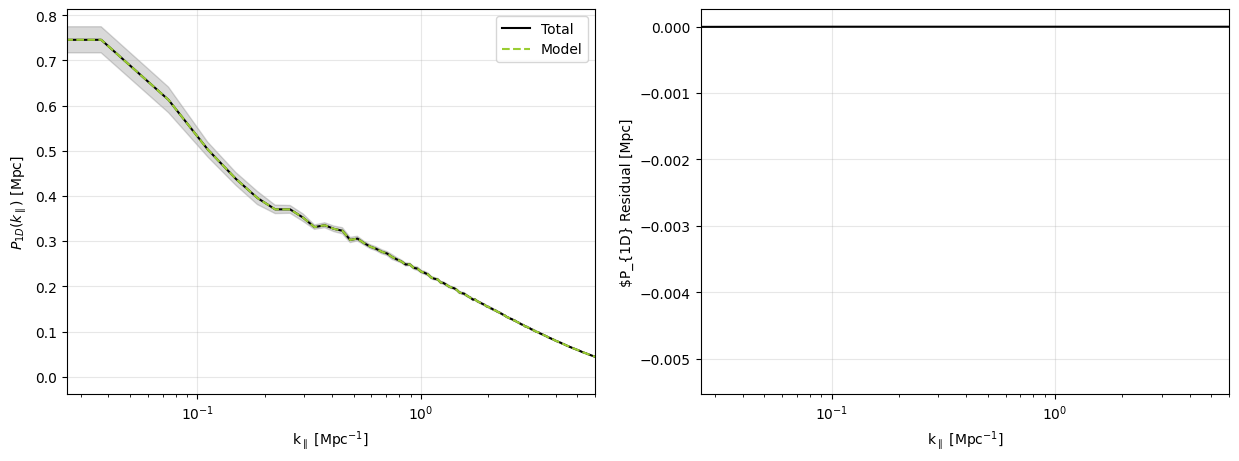

In [24]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_los, P1d_tot, color='k', label='Total')
plt.fill_between(k_los, (P1d_tot-P1d_std_tot), (P1d_tot+P1d_std_tot), color='k', alpha=0.15)
plt.plot(k_los, P1d_model, linestyle='--', color='yellowgreen', label='Model')

plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]');


plt.subplot(1, 2, 2)
plt.plot(k_los, P1d_tot-P1d_model, color='k')
plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D} Residual [Mpc]');

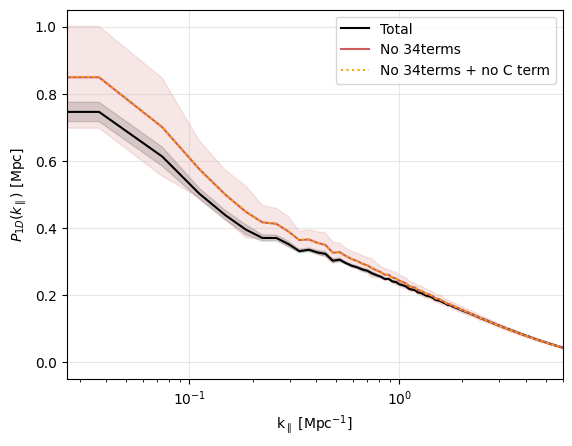

In [25]:
plt.plot(k_los, P1d_tot, color='k', label='Total')
plt.fill_between(k_los, (P1d_tot-P1d_std_tot), (P1d_tot+P1d_std_tot), color='k', alpha=0.15)
plt.plot(k_los, P1d_aprox, color='indianred', label='No 34terms')
plt.fill_between(k_los, (P1d_aprox-P1d_std_aprox), (P1d_aprox+P1d_std_aprox), color='indianred', alpha=0.15)
plt.plot(k_los, P1d_aprox_vega, color='orange', linestyle=':', label='No 34terms + no C term')
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]');

# To debug MW11

/tmp/ipykernel_594041/3920719540.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(k_los), P1d_hcd/P1d_lya, label='ASTRID')


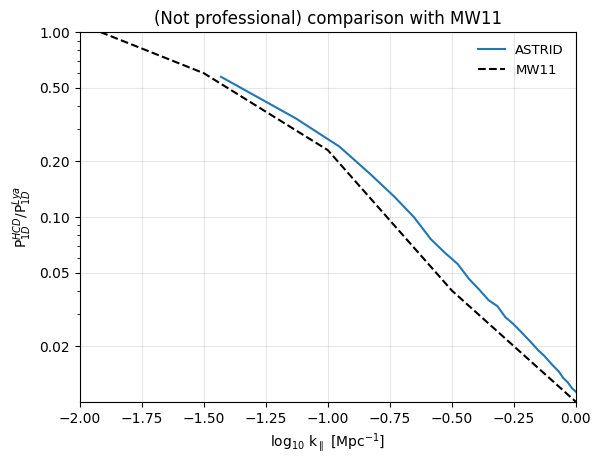

In [22]:
plt.plot(np.log10(k_los), P1d_hcd/P1d_lya, label='ASTRID')
plt.yscale('log')
yticks = np.array([0.02, 0.05, 0.10, 0.20, 0.50, 1.00, 2.00])
plt.plot([-2, -1.5, -1, -0.5, 0], [0.11+1, 0.1+0.5, 0.03+0.2, 0.04, 0.01], linestyle='--', color='k', label='MW11')
plt.yticks(yticks, [f"{y:.2f}" for y in yticks])
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'log$_{10}$ k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{1D}^{HCD}$/P$_{1D}^{Lya}$')
plt.xlim(-2, 0)
plt.ylim(0.01, 1)
plt.title('(Not professional) comparison with MW11');